# 11 — ML Meta-Label Model Training

Amaç, final Robot stratejisinin ürettiği sinyalleri olasılık bazında
sıralayacak ilk meta-label modellerini karşılaştırmaktır.

Bu aşamada:

- Rastgele train-test split kullanılmaz.
- Development döneminde purged expanding-window cross-validation uygulanır.
- Bir fold'un eğitim etiketleri validation başlangıcından önce kapanmış olmalıdır.
- Model ve eşik adayları yalnızca Validation döneminde değerlendirilir.
- `Audit_2025_Plus` henüz modele gösterilmez.
- Nihai olasılık eşiği bu notebook'ta seçilmez; portföy backtestinde seçilir.


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / "src").exists()
    else Path.cwd().parent
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from src.ml_dataset import BASE_FEATURE_COLUMNS
from src.ml_training import (
    build_candidate_models,
    create_purged_expanding_folds,
    folds_summary,
    cross_validate_models,
    summarize_cv_metrics,
    train_on_development_predict_validation,
    event_threshold_table,
    validation_permutation_importance,
    save_candidate_model,
)


## 1. Meta-label eğitim veri setini yükle


In [2]:
DATA_PATH = (
    PROJECT_ROOT
    / "results"
    / "ml"
    / "robot_meta_label_training.parquet"
)

dataset = pd.read_parquet(DATA_PATH)

date_columns = [
    "Signal_Date",
    "Entry_Date",
    "Exit_Date",
]

for column in date_columns:
    dataset[column] = pd.to_datetime(
        dataset[column]
    )

development = (
    dataset.loc[
        dataset["Period"].eq("Development")
    ]
    .sort_values(["Signal_Date", "Ticker"])
    .reset_index(drop=True)
)

validation = (
    dataset.loc[
        dataset["Period"].eq("Validation")
    ]
    .sort_values(["Signal_Date", "Ticker"])
    .reset_index(drop=True)
)

audit = (
    dataset.loc[
        dataset["Period"].eq("Audit_2025_Plus")
    ]
    .sort_values(["Signal_Date", "Ticker"])
    .reset_index(drop=True)
)

print("Development:", len(development))
print("Validation:", len(validation))
print("Audit — bu aşamada kullanılmayacak:", len(audit))
print("Özellik sayısı:", len(BASE_FEATURE_COLUMNS))


Development: 1851
Validation: 1098
Audit — bu aşamada kullanılmayacak: 930
Özellik sayısı: 31


## 2. Sınıf dengesizliği ve rejim değişimi

Accuracy ana metrik değildir. Başarılı sinyal oranı yaklaşık üçte bir olduğu
için PR-AUC, precision lift, Brier ve olay getirisi birlikte incelenecektir.


In [3]:
period_diagnostics = (
    dataset.groupby("Period")
    .agg(
        Event_Count=("Meta_Label", "size"),
        Positive_Rate=("Meta_Label", "mean"),
        Average_Return_=("Net_Return_%", "mean"),
        Median_Return_=("Net_Return_%", "median"),
        Average_R_Multiple=("R_Multiple", "mean"),
    )
    .reset_index()
)

period_diagnostics["Positive_Rate_%"] = (
    period_diagnostics["Positive_Rate"] * 100
)

display(period_diagnostics)


,Period,Event_Count,Positive_Rate,Average_Return_,Median_Return_,Average_R_Multiple,Positive_Rate_%
0,Audit_2025_Plus,930,0.273118,1.620498,-5.144132,0.210730,27.311828
1,Development,1851,0.411129,6.678966,-3.686008,1.140254,41.112912
2,Validation,1098,0.345173,4.325730,-5.017817,0.627123,34.517304


## 3. Purged expanding-window fold'ları oluştur


In [4]:
folds = create_purged_expanding_folds(
    development_data=development,
    n_splits=4,
    initial_train_fraction=0.40,
    embargo_days=5,
)

fold_table = folds_summary(
    data=development,
    folds=folds,
    target_column="Meta_Label",
)

display(fold_table)

if not fold_table["Purged_Correctly"].all():
    raise RuntimeError(
        "Purged fold kontrolü başarısız."
    )


,Fold,Train_Count,Validation_Count,Train_Positive_Rate_%,Validation_Positive_Rate_%,Train_Signal_End,Train_Exit_End,Validation_Start,Validation_End,Purged_Correctly
0,1,671,285,37.257824,34.035088,2020-10-05,2020-10-08,2020-10-19,2021-04-26,True
1,2,1006,239,37.176938,46.443515,2021-04-19,2021-04-21,2021-04-27,2021-12-10,True
2,3,1192,284,37.416107,33.450704,2021-11-26,2021-12-03,2021-12-13,2022-06-23,True
3,4,1501,314,37.375083,56.050955,2022-06-10,2022-06-17,2022-06-24,2022-12-30,True


## 4. Aday modeller


In [5]:
candidate_models = build_candidate_models(
    feature_columns=BASE_FEATURE_COLUMNS,
    random_state=42,
)

print("Modeller:")
for model_name in candidate_models:
    print("-", model_name)


Modeller:
- LogisticRegression
- RandomForest
- HistGradientBoosting


## 5. Development purged cross-validation


In [6]:
cv_fold_metrics, cv_oof_predictions = (
    cross_validate_models(
        development_data=development,
        feature_columns=BASE_FEATURE_COLUMNS,
        target_column="Meta_Label",
        models=candidate_models,
        folds=folds,
    )
)

cv_summary = summarize_cv_metrics(
    cv_fold_metrics
)

display(cv_summary)
display(
    cv_fold_metrics.sort_values(
        ["Model", "Fold"]
    )
)


,Model,ROC_AUC_mean,ROC_AUC_std,ROC_AUC_min,PR_AUC_mean,PR_AUC_std,PR_AUC_min,Brier_mean,Brier_std,Brier_min,...,Log_Loss_min,Precision_0_50_mean,Precision_0_50_std,Precision_0_50_min,Recall_0_50_mean,Recall_0_50_std,Recall_0_50_min,F1_0_50_mean,F1_0_50_std,F1_0_50_min
2,RandomForest,0.506385,0.099211,0.377165,0.459311,0.170120,0.277748,0.258037,0.037375,0.238432,...,0.670965,0.504580,0.190294,0.333333,0.209591,0.178275,0.010526,0.256006,0.194279,0.020408
1,LogisticRegression,0.532326,0.088341,0.457940,0.445591,0.117672,0.303499,0.262988,0.033267,0.215588,...,0.620089,0.379881,0.156837,0.250000,0.283090,0.241856,0.031579,0.291791,0.192303,0.056075
0,HistGradientBoosting,0.493425,0.090113,0.375439,0.434457,0.141323,0.265300,0.326750,0.080111,0.273219,...,0.806610,0.432912,0.226809,0.129032,0.155575,0.119902,0.042105,0.211713,0.145419,0.063492


,Positive_Rate_%,Predicted_Positive_Rate_%,PR_AUC,Brier,Log_Loss,Precision_0_50,Recall_0_50,F1_0_50,ROC_AUC,Model,Fold,Train_Count,Validation_Count,Validation_Start,Validation_End
8,34.035088,21.052632,0.370691,0.273219,0.823097,0.400000,0.247423,0.305732,0.551108,HistGradientBoosting,1,671,285,2020-10-19,2021-04-26
9,46.443515,22.594142,0.543492,0.282096,0.806610,0.555556,0.270270,0.363636,0.575028,HistGradientBoosting,2,1006,239,2021-04-27,2021-12-10
10,33.450704,10.915493,0.265300,0.306657,0.950944,0.129032,0.042105,0.063492,0.375439,HistGradientBoosting,3,1192,284,2021-12-13,2022-06-23
11,56.050955,5.414013,0.558343,0.445029,1.561698,0.647059,0.062500,0.113990,0.472126,HistGradientBoosting,4,1501,314,2022-06-24,2022-12-30
0,34.035088,30.175439,0.303499,0.274296,0.762190,0.255814,0.226804,0.240437,0.457940,LogisticRegression,1,671,285,2020-10-19,2021-04-26
1,46.443515,64.853556,0.478945,0.268907,0.732681,0.438710,0.612613,0.511278,0.461923,LogisticRegression,2,1006,239,2021-04-27,2021-12-10
2,33.450704,4.225352,0.415326,0.215588,0.620089,0.250000,0.031579,0.056075,0.639655,LogisticRegression,3,1192,284,2021-12-13,2022-06-23
3,56.050955,25.477707,0.584593,0.293161,0.792821,0.575000,0.261364,0.359375,0.569788,LogisticRegression,4,1501,314,2022-06-24,2022-12-30
4,34.035088,34.035088,0.351030,0.240191,0.673004,0.350515,0.350515,0.350515,0.536521,RandomForest,1,671,285,2020-10-19,2021-04-26
5,46.443515,27.196653,0.612209,0.239436,0.671842,0.630769,0.369369,0.465909,0.615146,RandomForest,2,1006,239,2021-04-27,2021-12-10


### Metrik yorumu

- **PR-AUC:** Sınıf dengesizliğinde ana sıralama metriği.
- **ROC-AUC:** Genel ayrıştırma gücü.
- **Brier:** Olasılık kalitesi; düşük olması daha iyi.
- **Precision:** Modelin seçtiği sinyallerin başarı oranı.
- **Recall:** Başarılı sinyallerin ne kadarının yakalandığı.

PR-AUC mutlaka o dönemin pozitif sınıf oranıyla karşılaştırılmalıdır.


## 6. Development'ta eğit, Validation'ı tahmin et


In [7]:
(
    fitted_models,
    validation_metrics,
    validation_predictions,
) = train_on_development_predict_validation(
    development_data=development,
    validation_data=validation,
    feature_columns=BASE_FEATURE_COLUMNS,
    target_column="Meta_Label",
    models=candidate_models,
    cutoff_date="2023-01-01",
    embargo_days=5,
)

display(validation_metrics)


,Positive_Rate_%,Predicted_Positive_Rate_%,PR_AUC,Brier,Log_Loss,Precision_0_50,Recall_0_50,F1_0_50,ROC_AUC,Model,Train_Count,Validation_Count,Train_Positive_Rate_%
1,34.517304,45.081967,0.358507,0.251150,0.695556,0.361616,0.472296,0.409611,0.530860,RandomForest,1777,1098,40.292628
0,34.517304,66.939891,0.356516,0.292490,0.790527,0.357823,0.693931,0.472172,0.529704,LogisticRegression,1777,1098,40.292628
2,34.517304,46.083789,0.338408,0.299947,0.828218,0.349802,0.467018,0.400000,0.490864,HistGradientBoosting,1777,1098,40.292628


## 7. Geçici model şampiyonunu belirle


In [8]:
champion_name = (
    validation_metrics.sort_values(
        ["PR_AUC", "Brier", "ROC_AUC"],
        ascending=[False, True, False],
    )
    .iloc[0]["Model"]
)

champion_model = fitted_models[champion_name]

champion_validation = (
    validation_predictions.loc[
        validation_predictions["Model"].eq(
            champion_name
        )
    ]
    .copy()
    .reset_index(drop=True)
)

print("Geçici model şampiyonu:", champion_name)
print(
    "Validation pozitif sınıf baz oranı:",
    round(
        champion_validation["Meta_Label"].mean(),
        4,
    ),
)


Geçici model şampiyonu: RandomForest
Validation pozitif sınıf baz oranı: 0.3452


Bu seçim yalnızca ilk aday model seçimidir. Nihai ML stratejisi sayılmamalıdır.
Bir sonraki adımda olasılık eşikleri event-driven portföy backtestine
entegre edilecektir.


## 8. Validation olasılık eşiklerinin olay kalitesi


In [9]:
threshold_table = event_threshold_table(
    predictions=champion_validation,
    probability_column="Probability",
)

minimum_selected_count = max(
    100,
    int(len(champion_validation) * 0.20),
)

threshold_shortlist = (
    threshold_table.loc[
        threshold_table["Selected_Count"].ge(
            minimum_selected_count
        )
        & threshold_table["Precision_Lift_pp"].gt(0)
        & threshold_table[
            "Average_Return_Lift_pp"
        ].gt(0)
    ]
    .sort_values(
        [
            "Average_R_Multiple",
            "Profit_Factor",
            "Precision_Lift_pp",
        ],
        ascending=False,
    )
    .head(10)
    .reset_index(drop=True)
)

print("TÜM EŞİKLER")
display(threshold_table)

print("PORTFÖY BACKTESTİNE TAŞINACAK KISA LİSTE")
display(threshold_shortlist)


TÜM EŞİKLER


,Threshold,Selected_Count,Selection_Rate_%,Precision_%,Precision_Lift_pp,Average_Return_%,Average_Return_Lift_pp,Median_Return_%,Average_R_Multiple,Median_R_Multiple,Profit_Factor,Average_Holding_Bars
0,0.250,1093,99.544627,34.583715,0.066410,4.369126,0.043396,-5.004151,0.633014,-0.879066,2.027836,16.720952
1,0.275,1080,98.360656,34.907407,0.390103,4.486967,0.161237,-4.926535,0.646210,-0.866014,2.066676,16.831481
2,0.300,1061,96.630237,34.967012,0.449708,4.553659,0.227929,-4.878515,0.652303,-0.859762,2.089823,16.905749
3,0.325,1029,93.715847,35.665695,1.148391,4.716855,0.391125,-4.825753,0.674817,-0.821036,2.147933,17.038873
4,0.350,988,89.981785,35.931174,1.413870,4.642735,0.317005,-4.777211,0.663395,-0.820575,2.134379,17.007085
5,0.375,936,85.245902,36.111111,1.593807,4.499064,0.173334,-4.738175,0.649160,-0.818050,2.102922,17.089744
6,0.400,856,77.959927,36.448598,1.931294,4.847380,0.521650,-4.667429,0.697066,-0.806637,2.208645,17.321262
7,0.425,783,71.311475,37.164751,2.647447,5.295944,0.970214,-4.532494,0.755374,-0.739283,2.351366,17.634738
8,0.450,700,63.752277,36.857143,2.339839,5.235619,0.909889,-4.516703,0.736487,-0.724798,2.356042,17.848571
9,0.475,593,54.007286,37.436762,2.919458,5.718264,1.392535,-4.468018,0.788650,-0.714672,2.514466,18.161889


PORTFÖY BACKTESTİNE TAŞINACAK KISA LİSTE


,Threshold,Selected_Count,Selection_Rate_%,Precision_%,Precision_Lift_pp,Average_Return_%,Average_Return_Lift_pp,Median_Return_%,Average_R_Multiple,Median_R_Multiple,Profit_Factor,Average_Holding_Bars
0,0.475,593,54.007286,37.436762,2.919458,5.718264,1.392535,-4.468018,0.788650,-0.714672,2.514466,18.161889
1,0.425,783,71.311475,37.164751,2.647447,5.295944,0.970214,-4.532494,0.755374,-0.739283,2.351366,17.634738
2,0.450,700,63.752277,36.857143,2.339839,5.235619,0.909889,-4.516703,0.736487,-0.724798,2.356042,17.848571
3,0.525,405,36.885246,35.308642,0.791338,5.005258,0.679528,-4.525583,0.705487,-0.775049,2.321460,17.535802
4,0.500,495,45.081967,36.161616,1.644312,5.032004,0.706275,-4.572976,0.697087,-0.770444,2.312554,17.838384
5,0.400,856,77.959927,36.448598,1.931294,4.847380,0.521650,-4.667429,0.697066,-0.806637,2.208645,17.321262
6,0.325,1029,93.715847,35.665695,1.148391,4.716855,0.391125,-4.825753,0.674817,-0.821036,2.147933,17.038873
7,0.350,988,89.981785,35.931174,1.413870,4.642735,0.317005,-4.777211,0.663395,-0.820575,2.134379,17.007085
8,0.300,1061,96.630237,34.967012,0.449708,4.553659,0.227929,-4.878515,0.652303,-0.859762,2.089823,16.905749
9,0.375,936,85.245902,36.111111,1.593807,4.499064,0.173334,-4.738175,0.649160,-0.818050,2.102922,17.089744


Eşik kısa listesi yalnızca aday üretir. En yüksek event getirili eşiği
doğrudan seçmek hatalı olabilir; yüksek eşik portföyü boş bırakabilir,
çeşitlendirmeyi azaltabilir veya işlem sıralamasını değiştirebilir.


## 9. Validation permutation importance


In [10]:
permutation_table = (
    validation_permutation_importance(
        fitted_model=champion_model,
        validation_data=validation,
        feature_columns=BASE_FEATURE_COLUMNS,
        target_column="Meta_Label",
        scoring="average_precision",
        n_repeats=20,
        random_state=42,
    )
)

display(permutation_table.head(20))


,Feature,Importance_Mean,Importance_Std
0,MARKET_VOLATILITY_20,0.006585,0.002772
1,VOLATILITY_20,0.005082,0.001680
2,RET_63,0.003857,0.006369
3,SCORE_RANK_PCT,0.003044,0.001099
4,RET_63_RANK_PCT,0.001857,0.001885
5,EMA50_SLOPE_5,0.001849,0.001482
6,VOLUME_RATIO,0.001547,0.001292
7,RET_20,0.001278,0.001069
8,RET_5,0.001049,0.001015
9,CLOSE_VS_EMA50,0.000960,0.001596


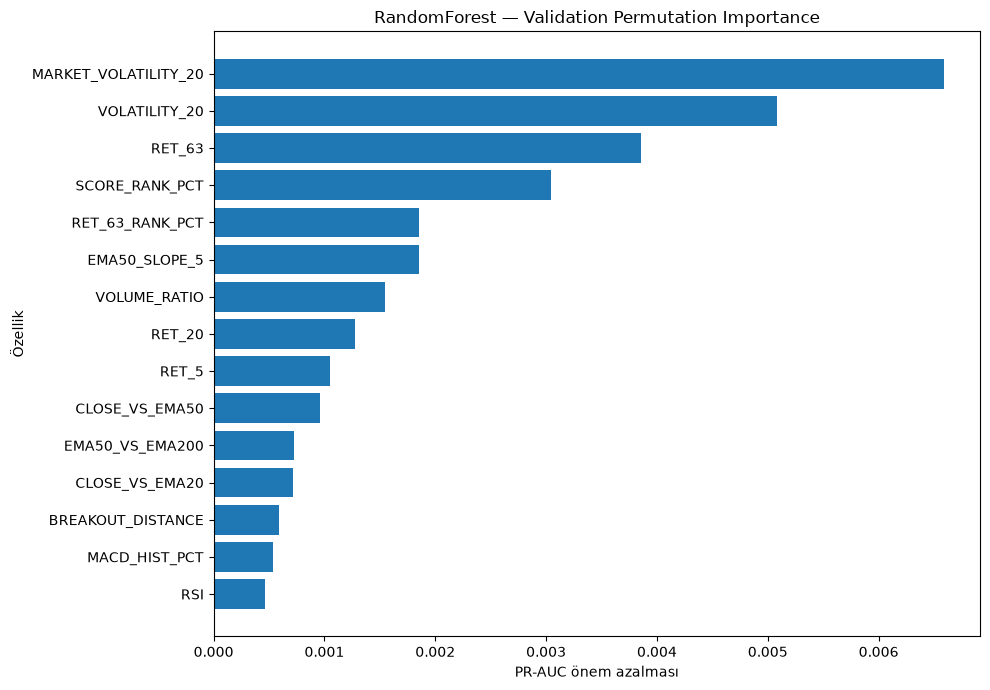

In [11]:
top_importance = permutation_table.head(15).sort_values(
    "Importance_Mean"
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_importance["Feature"],
    top_importance["Importance_Mean"],
)
plt.title(
    f"{champion_name} — Validation Permutation Importance"
)
plt.xlabel("PR-AUC önem azalması")
plt.ylabel("Özellik")
plt.tight_layout()
plt.show()


## 10. Sonuçları ve geçici modeli kaydet


In [12]:
ML_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "ml"
)
ML_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

cv_fold_metrics.to_csv(
    ML_RESULTS_DIR
    / "meta_label_cv_fold_metrics.csv",
    index=False,
)

cv_summary.to_csv(
    ML_RESULTS_DIR
    / "meta_label_cv_summary.csv",
    index=False,
)

cv_oof_predictions.to_parquet(
    ML_RESULTS_DIR
    / "meta_label_development_oof_predictions.parquet",
    index=False,
)

validation_metrics.to_csv(
    ML_RESULTS_DIR
    / "meta_label_validation_metrics.csv",
    index=False,
)

validation_predictions.to_parquet(
    ML_RESULTS_DIR
    / "meta_label_validation_predictions.parquet",
    index=False,
)

threshold_table.to_csv(
    ML_RESULTS_DIR
    / "meta_label_threshold_table.csv",
    index=False,
)

threshold_shortlist.to_csv(
    ML_RESULTS_DIR
    / "meta_label_threshold_shortlist.csv",
    index=False,
)

permutation_table.to_csv(
    ML_RESULTS_DIR
    / "meta_label_permutation_importance.csv",
    index=False,
)

model_path, metadata_path = save_candidate_model(
    model=champion_model,
    model_name=champion_name,
    feature_columns=BASE_FEATURE_COLUMNS,
    output_directory=MODEL_DIR,
    training_end="2022-12-31",
    target_column="Meta_Label",
)

print("Model:", model_path)
print("Metadata:", metadata_path)
print(
    "Audit dönemi modele gösterilmedi:",
    len(audit),
    "olay",
)


Model: c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\models\meta_label_candidate_model.joblib
Metadata: c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\models\meta_label_candidate_metadata.json
Audit dönemi modele gösterilmedi: 930 olay


## Sonraki aşama

Bir sonraki notebook:

1. Champion modelin validation olasılıklarını günlük Robot adaylarına bağlayacak.
2. Kısa listedeki olasılık eşiklerini event-driven portföy backtestinde çalıştıracak.
3. Her ML eşiğini orijinal Robot ve BIST100 ile karşılaştıracak.
4. İşlem sayısı, CAGR, drawdown, Profit Factor ve boşta kalma oranını birlikte değerlendirecek.
5. Eşik sabitlendikten sonra ilk kez `Audit_2025_Plus` raporu üretilecek.
